# Xarxa neuronal amb numpy

Aquest exemple no pretén fer una xarxa neuronal completa i funcional. Es tracta d'explorar el components que han de tenir. 

Comencem amb un dataset no lineal amb un única variable independent x. Aquesta es genera amb números aleatoris. La variable y es calcula amb una funció que mescla potències amb un sinus, per tant, la gràfica no és lineal. No afegim soroll per veure més clarament la forma de la gràfica. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.random.rand(1000,1)
y = 0.5*x**3 - 5*x**2 + 5*np.sin(x*10)


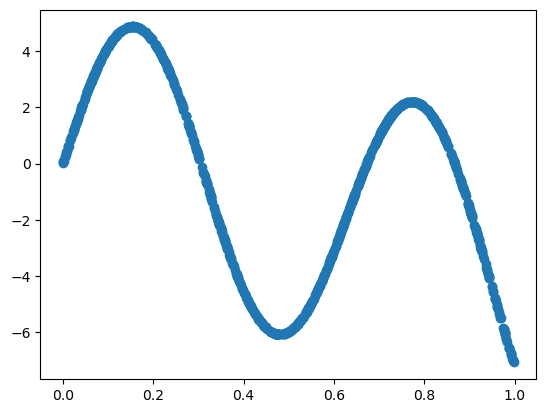

In [3]:
plt.scatter(x=x, y=y)

In [4]:
data = np.c_[x,y]

In [5]:
df = pd.DataFrame(data, columns=['X','Y'])
df

,X,Y
0,0.196558,4.426027
1,0.413852,-5.019959
2,0.789522,2.125095
3,0.747800,2.063796
4,0.058761,2.754712
...,...,...
995,0.996108,-7.021797
996,0.212642,4.026585
997,0.006232,0.311216
998,0.383864,-3.918278


El model bàsic de regressió lineal no arriba a ajustar a les dades per se una línia. En aquest cas, amb machine learning podem utilitzar un model polinómic, basat en distàncies o basat en arbres. No ens interessa explorar aquests algorismes ara, es tracta de demostrar cóm el deep learning pot aprendre formes complexes. 

In [6]:
# Model de regressió lineal

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)  # 80% per a entrenament, 20% per a prova
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)  # Calcular l'Error Quadràtic Mitjà (MSE)
rmse = np.sqrt(mse)  # Calcular l'Arrel de l'Error Quadràtic Mitjà (RMSE)
r2 = r2_score(y_test, y_pred)  # Calcular el Coeficient de Determinació (R²)
intercept = model.intercept_[0]  # Obtenir el terme independent (intercepta)
coefficient = model.coef_[0][0]  # Obtenir el coeficient de la variable X
print(f"Equació del model: y = {coefficient:.4f}X + {intercept:.4f}")
print(f"MSE {mse:.2f} RMSE {rmse} R2 {r2}")

Equació del model: y = -5.1764X + 2.0515
MSE 9.77 RMSE 3.1254638987631282 R2 0.15929095693806272


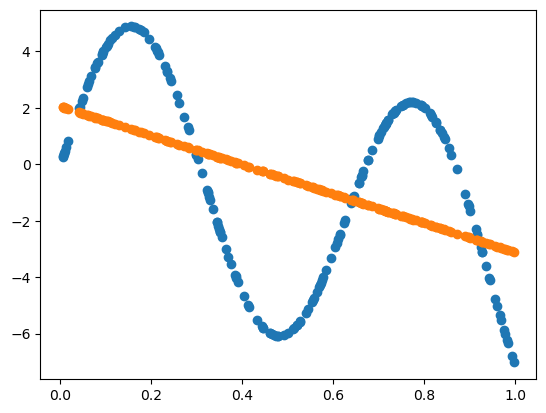

In [8]:
plt.scatter(x=X_test, y=y_test)
plt.scatter(x=X_test, y=y_pred)

In [9]:
# L'idea és crear una "xarxa neuronal" de 2 neurones d'entrada i una eixida. 
# LinealRegression té un error MSE per defecte i caldria modificar la seua funció
# d'error en funció del resultat total amb backpropagation
# Per tant, cal fer una regressió lineal manual amb una funció de loss personalitzada.

# Mirar si LinealRegression permet multi value o fan falta 2 
# Mirar si LinealRegression permet personalitzar la funcio de pérdua
# Mirar com connectar l'eixida de dos com a entrada d'una lineal regression
# Es podria fer un bucle en el que les dos neurones inicials fan una predicció aleatoria
# Generen un dataset de X1,X2 que passa a la segona capa i eixa es compara amb el resultat esperat. i es fa el backpropagation 

L'idea és crear una "xarxa neuronal" de 2 neurones d'entrada i una eixida. Els perceptrons lineals tenen la mateixa base matemàtica que `LinearRegression` de Scikit-learn. Però a diferència d'aquesta ferramenta, la seua funció de cost no depèn únicament de les prediccions individuals, sinò que ve donada per les prediccions de la xarxa neuronal completa. Per això no podem utilitzar `LinearRegression` per emular una xarxa neuronal bàsica. 

Amés, matemàticament, si la xarxa és de perceptrons lineals, sempre serà equivalent a una única regressió lineal. Per tant caldrà afegir una funció d'activació diferent. 

El següent exemple crea manualment dos neurones d'entrada i una d'eixida, fa un entrenament i executa un backpropagation bàsic amb la derivada de l'error. Ho fa amb la funció `dot` per fer multiplicacions de matrius. Tenim en compte que els pesos estan en matrius en aquest cas, per aproximar-se més al càlcul real. 

In [10]:
import numpy as np

X = X_train
y = y_train

np.random.seed(42)
N = X.shape[0]

# 1. Inicialització de pesos
W1 = np.random.randn(1, 2)  # Capa 1: 1 entrada -> 2 neurones
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1)  # Capa 2: 2 entrades -> 1 eixida
b2 = np.zeros((1, 1))

lr = 0.01

for epoch in range(1000):
    # --- PASSADA ENDAVANT (Forward Pass) ---
    h = np.dot(X, W1) + b1       # Output capa 1, shape (N, 2)
    y_pred = np.dot(h, W2) + b2  # Output capa 2, shape (N, 1)
    
    # --- CÀLCUL DE L'ERROR EN L'EIXIDA (Capa 2) ---
    delta2 = (y_pred - y) / N    # Gradient d'eixida, shape (N, 1)
    dW2 = np.dot(h.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)
    
    # --- PROPAGACIÓ DE L'ERROR A LA CAPA OCULTA (Capa 1) ---
    delta1 = np.dot(delta2, W2.T) # Error atribuït a la capa 1, shape (N, 2)
    dW1 = np.dot(X.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)
    
    # --- ACTUALITZACIÓ DE PESOS (SGD) ---
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

print("Pesos finals Capa 1 (W1):\n", W1)
print("Pesos finals Capa 2 (W2):\n", W2)

Pesos finals Capa 1 (W1):
 [[ 0.00590262 -1.99488409]]
Pesos finals Capa 2 (W2):
 [[0.43345173]
 [2.58768336]]


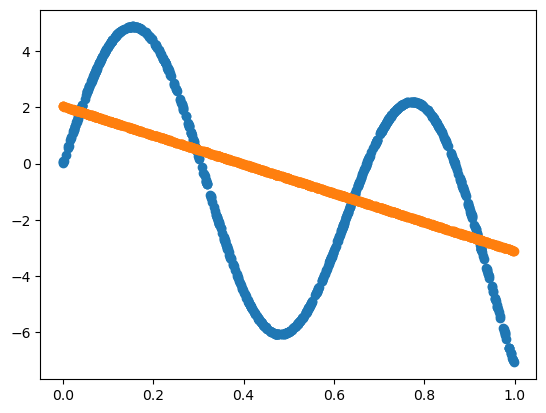

In [11]:
plt.scatter(x=X_train, y=y_train)
plt.scatter(x=X_train, y=y_pred)

Si no hi ha una funció d'activació no lineal entremig, **tota la xarxa continua sent estrictament lineal**, independentment de quantes capes o neurones hi posem.

El següent exemple aplica una funció sigmoide


In [12]:
import numpy as np

# Funció d'activació sigmoide i la seua derivada respecte a l'activació
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    # a = sigmoid(z), per tant d/dz sigmoid(z) = a * (1 - a)
    return a * (1 - a)

# Dades d'entrenament
X = X_train
y = y_train
np.random.seed(42)
N = X.shape[0]

# 1. Inicialització de pesos
W1 = np.random.randn(1, 2)  # Capa 1: 1 entrada -> 2 neurones
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1)  # Capa 2: 2 entrades -> 1 eixida
b2 = np.zeros((1, 1))

lr = 0.1  # Taxa d'aprenentatge
epochs = 5000

for epoch in range(epochs):
    # --- PASSADA ENDAVANT (Forward Pass) ---
    z1 = np.dot(X, W1) + b1       # Entrada lineal a la capa 1
    a1 = sigmoid(z1)              # Activació Sigmoide: h = σ(z1)
    y_pred = np.dot(a1, W2) + b2  # Predicció final d'eixida (lineal)
    
    # --- PROPAGACIÓ CAP ENRERE (Backpropagation) ---
    # Gradient de la capa d'eixida
    delta2 = (y_pred - y) / N    # dL / dy_pred
    dW2 = np.dot(a1.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)
    
    # Gradient de la capa oculta (APLICANT LA REGLA DE LA CADENA)
    # δ1 = (δ2 · W2^T) ⊙ σ'(z1)
    delta1 = np.dot(delta2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)
    
    # --- ACTUALITZACIÓ DE PESOS ---
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

# Results
print("--- RESULTATS DE L'ENTRENAMENT ---")
#print("Prediccions finals (y_pred):\n", np.round(y_pred, 2))
#print("\nPesos finals Capa 1 (W1):\n", W1)
#print("Bias final Capa 1 (b1):\n", b1)
#print("\nPesos finals Capa 2 (W2):\n", W2)
#print("Bias final Capa 2 (b2):\n", b2)

--- RESULTATS DE L'ENTRENAMENT ---


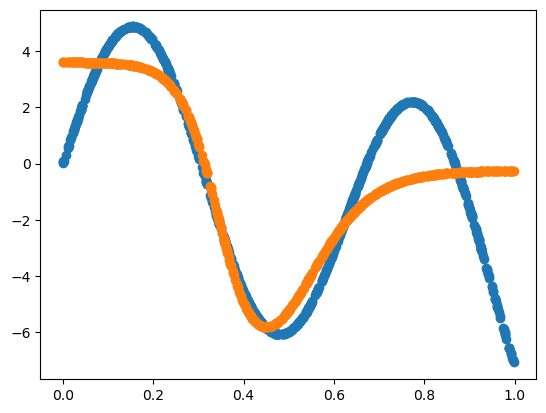

In [13]:
plt.scatter(x=X_train, y=y_train)
plt.scatter(x=X_train, y=y_pred)

El resultat és molt bo per a sols dos capes tant simples, però té carències als extrems, ja que els sigmoides tenen valors "plans" amb X molt grans o menuts. 